# 02 · Reflection (Generate → Critique → Improve)

**Idea:** One model call writes a draft; a second call *critiques* it; the draft is rewritten using the critique.
Repeat until the critic is happy (or a max-loop limit is hit).

```
START -> generate -> reflect --(approved or max loops)--> END
             ^           |
             +-----------+  (needs work: feedback goes back)
```

Also known as **Evaluator-Optimizer** or **Self-Refine**.
**Use when:** quality matters more than speed (writing, code, summaries).

In [1]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

In [2]:
from typing import TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

MAX_LOOPS = 3   # ALWAYS cap loops, or a picky critic will spin forever

class Critique(BaseModel):
    approved: bool = Field(description="True only if the draft is clear, specific and under 60 words")
    feedback: str = Field(description="One or two concrete improvements. Empty if approved.")

class State(TypedDict):
    topic: str
    draft: str
    feedback: str
    loops: int

In [3]:
def generate(state: State):
    """Writer: produce a draft. On later loops it also sees the critic's feedback."""
    prompt = f"Write a short product pitch (max 60 words) for: {state['topic']}."
    if state.get("feedback"):
        prompt += f"\n\nYour previous draft:\n{state['draft']}\n\nImprove it using this feedback:\n{state['feedback']}"
    draft = llm.invoke(prompt).content
    print(f"✍️  Draft #{state.get('loops', 0) + 1}:\n{draft}\n")
    return {"draft": draft, "loops": state.get("loops", 0) + 1}


def reflect(state: State):
    """Critic: a separate LLM call with a different role. Returns structured feedback."""
    critic = llm.with_structured_output(Critique)
    review = critic.invoke(
        "You are a strict editor. Review this pitch for clarity and specificity.\n"
        f"Pitch: {state['draft']}"
    )
    print(f"🔍 Critic -> approved={review.approved}  feedback={review.feedback!r}\n")
    return {"feedback": "" if review.approved else review.feedback}


def should_continue(state: State):
    """Stop when there is no feedback left OR we hit the loop limit."""
    if not state["feedback"] or state["loops"] >= MAX_LOOPS:
        return END
    return "generate"

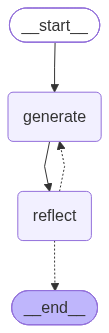

✍️  Draft #1:
Introducing HydraTrack - a revolutionary, BPA-free water bottle that tracks your hydration levels. With a built-in sensor and mobile app, HydraTrack monitors your water intake and sends reminders to stay on track. Customizable goals and alerts ensure you're drinking enough throughout the day. Stay hydrated, stay healthy, with HydraTrack.

🔍 Critic -> approved=False  feedback="While the pitch is clear on the overall concept, it lacks specificity and detail. Here's a revised version with suggested improvements: }"

✍️  Draft #2:
Here's a revised pitch:

"Meet HydraTrack, a smart, BPA-free water bottle that tracks your daily hydration. With a built-in sensor and mobile app, HydraTrack monitors your water intake, sends personalized reminders, and sets customizable goals. Receive alerts when you're low on water, and track your progress over time. Stay hydrated, stay healthy, with HydraTrack's accurate tracking and motivational features."

I made the following changes:

* Added

In [4]:
builder = StateGraph(State)
builder.add_node("generate", generate)
builder.add_node("reflect", reflect)
builder.add_edge(START, "generate")
builder.add_edge("generate", "reflect")
builder.add_conditional_edges("reflect", should_continue, ["generate", END])
graph = builder.compile()
from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))
final = graph.invoke({"topic": "a reusable water bottle that tracks hydration", "loops": 0, "feedback": ""})
print("✅ FINAL:\n", final["draft"])

### Tips
* The critic can be a **different / smaller model** (e.g. `small_llm`) to save time — but a bigger critic finds more problems.
* Give the critic a **rubric** (as above: "under 60 words") so feedback is checkable, not vague.
* For code, make the critic a *real tool* (run the tests / linter) — far better than an LLM opinion.